In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3

In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query = ''' 
       SELECT name 
       FROM sqlite_master
       WHERE type = 'table'
 '''

tables = pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}" , conn) 
    globals()[f"df_{table_name}"] = df 
    print(f"Created dataframe : df_{table_name}")

conn.close()
    

Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


In [3]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [4]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [5]:
  df_db_customer.rename(columns= {'name' : 'customer_name'},inplace= True)

In [6]:
df_db_customer.drop(columns= ['interests' , 'pincode'],inplace=True)

In [7]:
df_db_customer['dob'] =  pd.to_datetime(df_db_customer['dob'])

In [8]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [9]:
df_db_customer['gender'] = df_db_customer['gender'].replace(
    {'Men' : 'Male' , 
    'Women' : 'Female'}
)

In [10]:
df_db_customer['country'].isnull().sum()

np.int64(3)

In [11]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [12]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [13]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [14]:
df_db_subscription.shape

(21, 11)

In [15]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [16]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [17]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [18]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [19]:
df_db_support['escalations'].unique()

array(['N', 'Y'], dtype=object)

In [20]:
df_db_support.drop(columns= ['col_1','comment'],inplace = True)

In [21]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [22]:
# 3. Feature  Engineering and Data Analysis 

In [23]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34


In [24]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna() , 1, 0)

In [25]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0


In [26]:
# first fix support table duplicates and then merge
df = (df_db_subscription
                        .merge(df_db_customer, on = 'customerid',how= 'left')
                         .merge(df_db_support, on = 'customerid' , how= 'left'))

In [27]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0


In [28]:
df_db_subscription.shape

(21, 12)

In [29]:
df.shape

(23, 20)

In [30]:
df_db_subscription['customerid'].nunique()

21

In [31]:
df_db_customer['customerid'].nunique()

21

In [32]:
df_db_support['customerid'].nunique()

7

In [33]:
df_db_support['customerid'].size


9

In [34]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [35]:
df_db_support.head(2)

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2


In [36]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid' , keep= 'last')

In [37]:
df_db_support['customerid'].size

7

In [38]:
# After fixing duplicates merge 
df = (df_db_subscription
                       .merge(df_db_customer , on = 'customerid' , how= 'left')
                       .merge(df_db_support , on = 'customerid' , how='left'))

In [39]:
df.shape

(21, 21)

In [40]:
df.to_csv('exported_churn_data.csv' , index=False)

In [41]:
# Data Analysis 

In [42]:
 df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [43]:
# 1. Churn Rate 

In [44]:
churn_rate = df['churn_flag'].mean()*100
print('Churn Rate = ', round(churn_rate,2),'%')

Churn Rate =  28.57 %


In [45]:
# 2. Retention Rate 

In [46]:
retention_rate =  100- churn_rate
print('Retention Rate = ' , round(retention_rate , 2 ) , '%')

Retention Rate =  71.43 %


In [47]:
# 3. Churn by Plan type

In [48]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [49]:
# 5. ARPU - Avg Revenue per user 

In [50]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [51]:
arpu = df['monthly_charges'].mean()
print('ARPU = ' , round(arpu , 2))

ARPU =  18.85


In [52]:
# 6. Avg Customer Tenure 
# count  of days users has used our service : cancellation date else current date 

In [53]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
               df['cancellation_date'].notna(),

          (df['cancellation_date'] - df['subscription_start_date']).dt.days , 
           (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days) = ' ,round(avg_tenure),0)

Avg Tenure (Days) =  1493 0


In [54]:
#7. Revenue at risk 

In [55]:
revenue_at_risk = df.loc[df['churn_flag'] == 1,'monthly_charges'].sum()
print('Revenue at Risk (Rs "K") = ' ,revenue_at_risk)

Revenue at Risk (Rs "K") =  73.94


In [56]:
# 8. Escalation Rate 

In [57]:
escalation_rate = (df['escalations'] == 'Y').mean()*(100)
print('Escalation Rate = ',round(escalation_rate,2) , '%')

Escalation Rate =  19.05 %


In [58]:
# 9. Avg Complaint Per User 

In [59]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print('Avg Complaints Per User = ' , round(avg_complaints , 2))

Avg Complaints Per User =  0.43


In [60]:
# 10. Correlation Escalation vs Churn 

In [61]:
df['escalations'] = np.where(df['escalations'] == 'Y' , 1,0) # encoding string to int type 
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print('Correalation between escalation vs churn is = ' , round(correlation , 2 ))

Correalation between escalation vs churn is =  0.77


In [62]:
# 11. churn risk - create a column using the existing col 

In [63]:
conditions = [
    (df['churn_score'] < 50), 
    (df['churn_score']>= 50) & (df['churn_score'] < 70),
    (df['churn_score']>= 70)
    
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions,choices,default='unkown')

In [64]:
df[['churn_risk' , 'churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [65]:
## 4.Visualization using Matplotlib

In [66]:
df_visual = df.copy()

In [67]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [68]:
# 4.1 Monthly Churn Trend

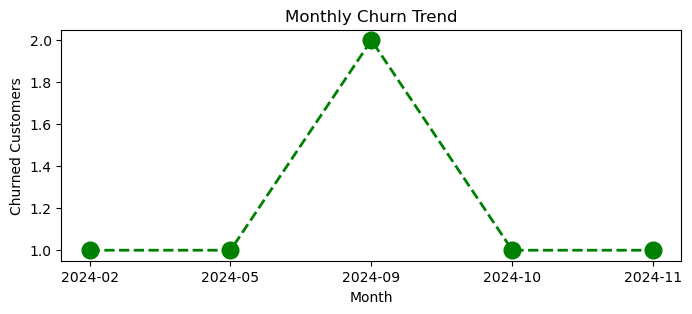

In [69]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color ='green',marker = 'o' , linestyle = 'dashed', linewidth = 2,markersize = 12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [70]:
# 4.2 Churn by Plan Type 

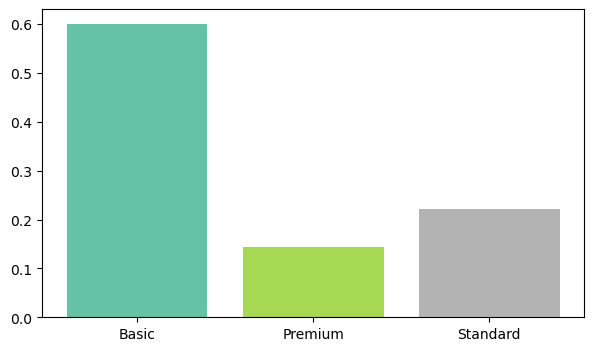

In [71]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['teal' , 'blue' , 'navy']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [72]:
# 4.3 Chrun by States 

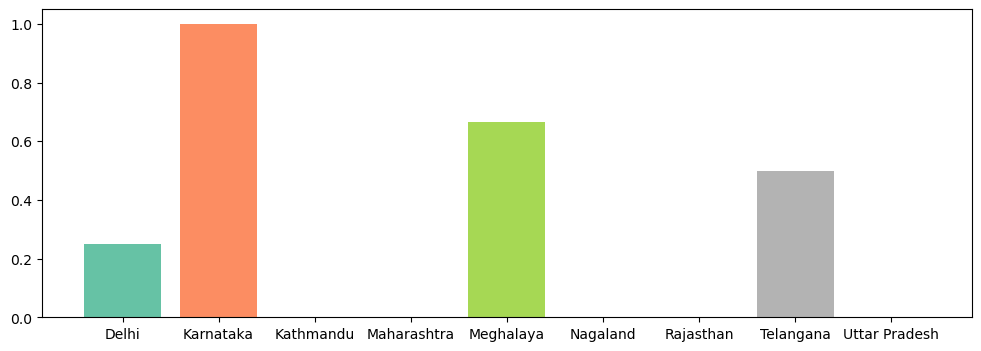

In [73]:
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [74]:
# Visualization using Seaborn

In [75]:
#encoding = covert str to numeric so that we can find corr between features 

In [76]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [77]:
import warnings
warnings.filterwarnings("ignore")

In [78]:
# incorrect method of encoding - asnumbers are not assigned based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols = ['plan_type' , 'contract_type' , 'churn_risk']

for cols in categorical_cols:
   df_encoded[cols] = df_encoded[cols].astype('category').cat.codes

<Axes: >

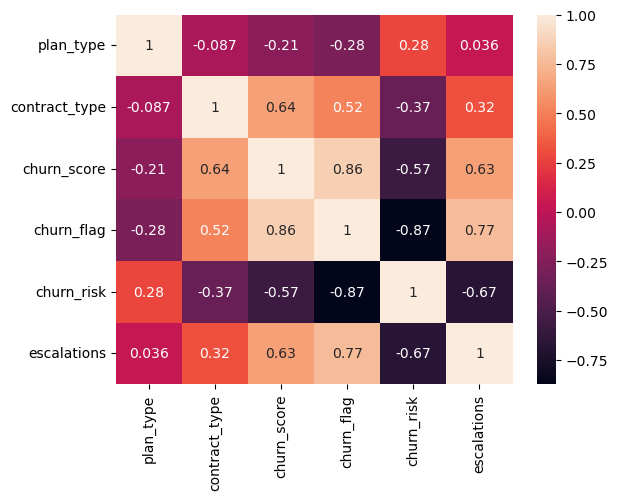

In [79]:
sns.heatmap(df_encoded.corr(),annot=True)

In [80]:
# correct method of encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {'plan_type' : ['Basic', 'Standard' , 'Premium'] ,
                  'contract_type' : ['Monthly' ,'Annual'],
                  'churn_risk' : ['low','med','high']}

for col,order  in order_mappings.items():
   df_encoded[col] =pd.Categorical(df_encoded[col].astype('category'), categories=order,ordered=True).codes

<Axes: >

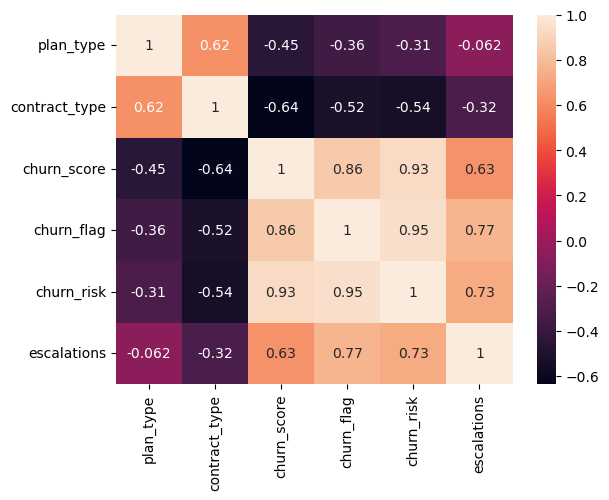

In [81]:
sns.heatmap(df_encoded.corr(),annot=True)

In [82]:
 #pairplot - relationship in a dataset

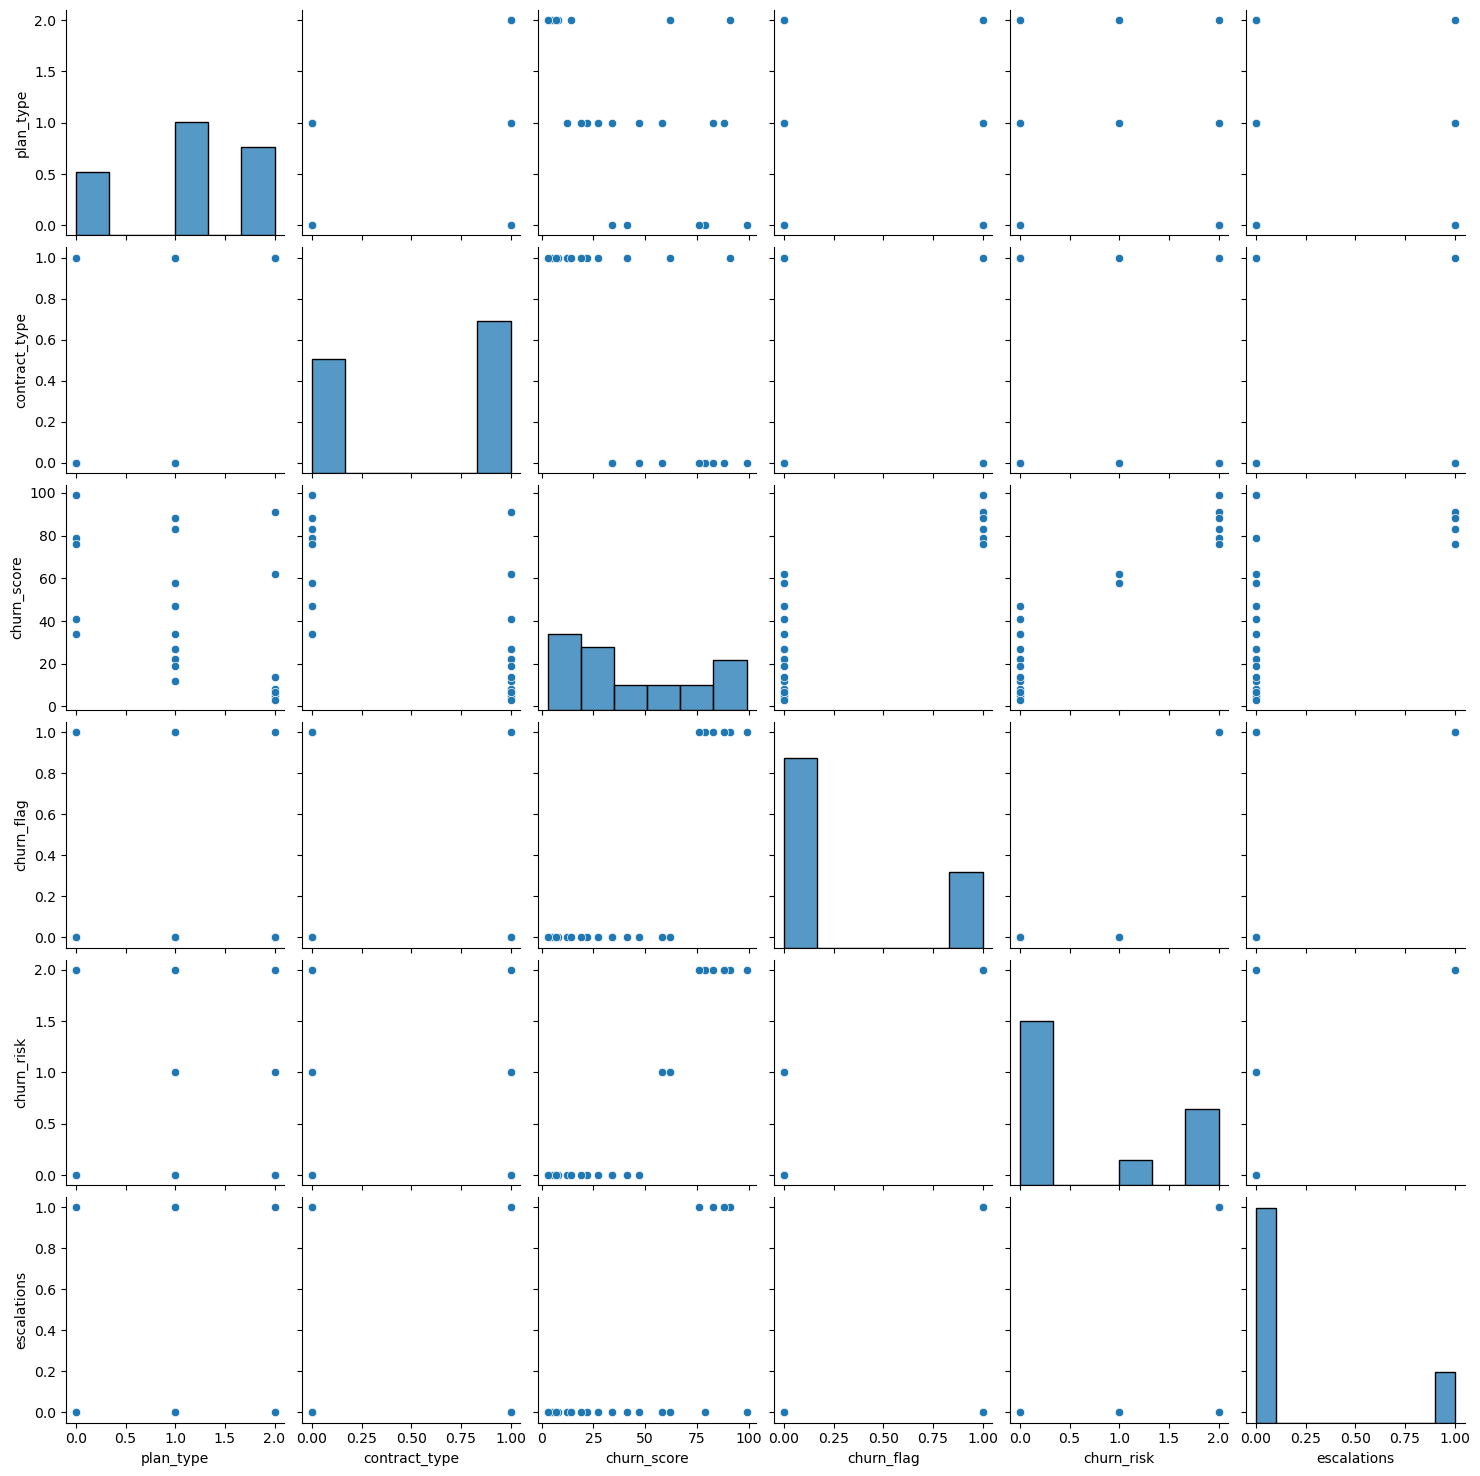

In [83]:
sns.pairplot(df_encoded)

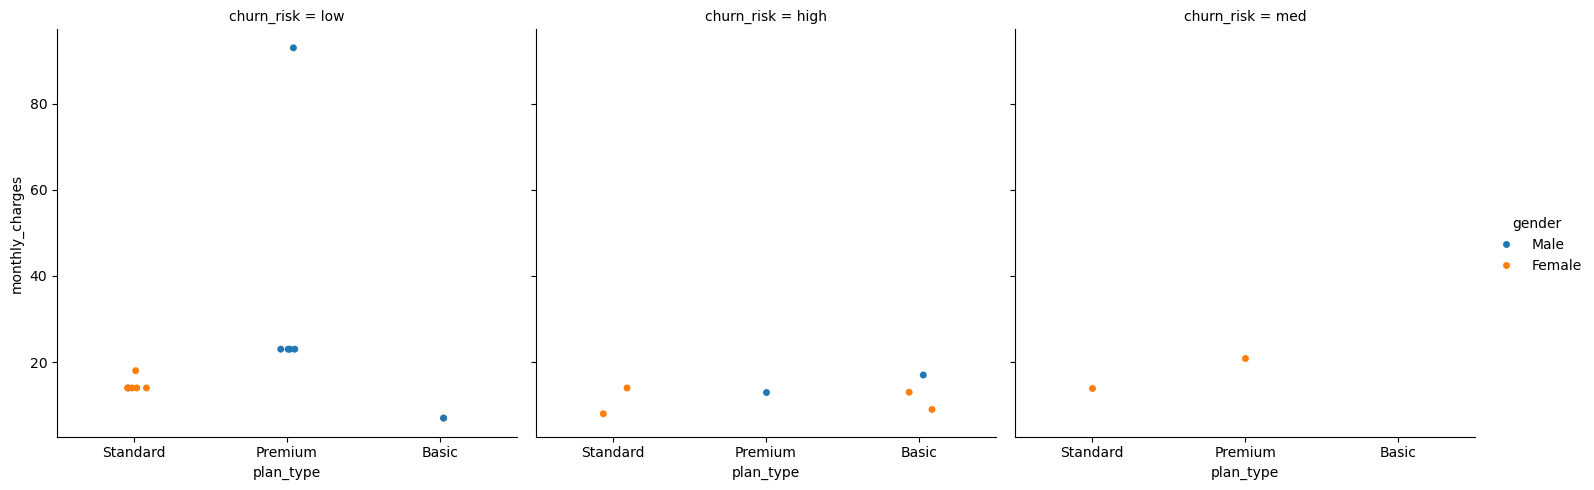

In [84]:
# catplt/Facegrid plot 

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges', 
    hue='gender',
    col= 'churn_risk'
)

In [85]:
#Pivot Table

In [86]:
pd.pivot_table(
    df_visual,
    values='churn_flag', 
    index='plan_type',  
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [87]:
pd.pivot_table(
    df_visual,
    index='plan_type', 
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
         'monthly_charges' : 'sum',
         'customerid' : 'nunique', 
         'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [88]:
# Working with SQL in Python (pandas)

In [89]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT , country TEXT , budget INTEGER)")

#commit and save
conn.commit()

In [95]:
# insert data 

cursor = conn.cursor()

cursor.execute("""
INSERT INTO users VALUES
('Madhav', 'India', 5000),
('Rishabh', 'Germany', 2500),
('Vishakha', 'India', 3500)
""")
conn.commit()
print('Data Inserted Succesfully!')

Data Inserted Succesfully!


In [96]:
conn = sqlite3.connect('test_database.sqlite') 

query = """SELECT * FROM users"""

df_results = pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [97]:
# aggregation 
query = """
        SELECT country,sum(budget) as total_budget 
        FROM users
        GROUP BY country
"""


df_agg = pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [98]:
conn.close()